# CS-4063: Natural Language Processing — Assignment 3
## Transformers + RAG: Amazon Reviews Sentiment Analysis & Explanation Generation

**Course:** CS-4063 Natural Language Processing  
**Due Date:** 29-04-26, 11:59 PM  


## System Overview
| Part | What it does |
|------|-------------|
| **Part A** | Encoder-only Transformer — sentiment (3-class) + review length (3-class) multi-task |
| **Part B** | Cosine-similarity retrieval over encoder embeddings |
| **Part C** | Decoder-only Transformer — autoregressive explanation generation with RAG |


In [1]:
#import subprocess, sys
#subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
#    'torch==2.3.0', 'torchvision', 'torchaudio',
#    '--index-url', 'https://download.pytorch.org/whl/cu121'], check=True)
#print("Done — now go to Run menu → Restart Session, then Run All")

In [2]:
# Install / verify required packages (all standard on Kaggle)
!pip install torch numpy pandas matplotlib seaborn scikit-learn tqdm nltk -q
print("Packages ready.")


Packages ready.


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import json, os, random, math, re
from collections import Counter

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

# ── Reproducibility ──────────────────────────
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# ── Device ───────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ── Output directories ───────────────────────
os.makedirs('models',  exist_ok=True)
os.makedirs('results', exist_ok=True)
print("Directories ready: models/, results/")


Device: cuda
Directories ready: models/, results/


## Hyperparameter Configuration
All tunable values live here — change once, propagates everywhere.

In [4]:
# ═══════════════════════════════════════════════════════════════
#  HYPERPARAMETERS  — edit here only
# ═══════════════════════════════════════════════════════════════

# Data
SAMPLES_PER_CLASS   = 15_000
MAX_SEQ_LEN         = 128
MIN_WORD_FREQ       = 2

# Encoder
EMBED_DIM           = 256
NUM_HEADS           = 8
FF_DIM              = 512
NUM_ENCODER_LAYERS  = 4
DROPOUT             = 0.1

# Training
BATCH_SIZE          = 128
GRAD_ACCUM_STEPS    = 2        # effective batch = 256
ENCODER_LR          = 1e-4
NUM_EPOCHS          = 35
WARMUP_STEPS        = 200

# Retrieval
TOP_K               = 3

# Decoder
DECODER_EMBED_DIM   = 256
DECODER_HEADS       = 8
DECODER_FF_DIM      = 512
NUM_DECODER_LAYERS  = 4
DECODER_MAX_LEN     = 50       # max NEW tokens to generate
DECODER_SEQ_LEN     = 160      # total sequence budget (prompt + explanation)
EXPL_RESERVE        = 30       # tokens reserved for explanation in the sequence
DECODER_LR          = 2e-4
DECODER_EPOCHS      = 20

print("Hyperparameters set.")
print(f"  Dataset target : {3*SAMPLES_PER_CLASS:,} reviews")
print(f"  Encoder        : {NUM_ENCODER_LAYERS}L × {NUM_HEADS}H × d={EMBED_DIM}")
print(f"  Decoder        : {NUM_DECODER_LAYERS}L × {DECODER_HEADS}H × d={DECODER_EMBED_DIM}")
print(f"  Decoder seq budget: {DECODER_SEQ_LEN} tokens ({EXPL_RESERVE} reserved for explanation)")


Hyperparameters set.
  Dataset target : 45,000 reviews
  Encoder        : 4L × 8H × d=256
  Decoder        : 4L × 8H × d=256
  Decoder seq budget: 160 tokens (30 reserved for explanation)


## Part 0 — Dataset Preparation

**Source:** Amazon Reviews dataset — 4 product categories loaded directly from JSON files.
- `Beauty_5.json` — 198,502 reviews
- `Cell_Phones_and_Accessories_5.json` — 194,439 reviews  
- `Home_and_Kitchen_5.json` — 551,682 reviews
- `Sports_and_Outdoors_5.json` — 296,337 reviews

**Diversity:** 4 categories covering personal care, electronics, household, and sports — ensuring broad linguistic and topical coverage.

**Sampling:** Up to 15,000 reviews per sentiment class per category to build a balanced subset of 30,000–45,000 samples.


In [5]:
import os, json

# ══════════════════════════════════════════════════════════════════
#  DATA FILE PATHS
#  Categories: Beauty, Cell Phones, Home & Kitchen,
#              Sports & Outdoors, Electronics  (5 categories)
#
#  Kaggle dataset path:
#  /kaggle/input/datasets/ishmalfaheem/amazon-revs/
# ══════════════════════════════════════════════════════════════════

KAGGLE_DIR = "/kaggle/input/datasets/ishmalfaheem/amazon-revs"

def find_file(filename):
    """Auto-detect file location across Kaggle, Colab, and local."""
    for p in [
        f"{KAGGLE_DIR}/{filename}",          # Kaggle
        f"/content/{filename}",              # Google Colab
        f"./{filename}",                     # same folder as notebook
        f"../data/{filename}",               # data/ subfolder
        f"/mnt/user-data/uploads/{filename}" # Claude sandbox
    ]:
        if os.path.exists(p):
            return p
    return None

JSON_FILES = {
    'Beauty':              'Beauty_5.json',
    'Cell_Phones':         'Cell_Phones_and_Accessories_5.json',
    'Electronics':         'Electronics_5.json',
    'Home_and_Kitchen':    'Home_and_Kitchen_5.json',
    'Sports_and_Outdoors': 'Sports_and_Outdoors_5.json',
}

def load_amazon_json(path, category):
    """Load Amazon review JSON (one object per line). Uses reviewText + overall."""
    records = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                obj    = json.loads(line)
                text   = str(obj.get('reviewText', '') or '').strip()
                rating = float(obj.get('overall', 0))
                if text and 1.0 <= rating <= 5.0:
                    records.append({'review': text, 'rating': rating,
                                    'category': category})
            except Exception:
                continue
    return records

# ── Load all 5 categories ─────────────────────────────────────────────────────
all_records = []
for cat, fname in JSON_FILES.items():
    path = find_file(fname)
    if path is None:
        print(f"WARNING: {fname} not found — skipping {cat}")
        print(f"  Searched: {KAGGLE_DIR}/, /content/, ./")
        continue
    print(f"Loading {cat} from {path} ...")
    recs = load_amazon_json(path, cat)
    print(f"  -> {len(recs):,} reviews")
    all_records.extend(recs)

if len(all_records) == 0:
    raise FileNotFoundError(
        "No data files found. Check that KAGGLE_DIR path is correct.")

df_raw = pd.DataFrame(all_records)
print(f"\nTotal loaded: {len(df_raw):,} reviews across {df_raw['category'].nunique()} categories")
print(f"Category distribution:\n{df_raw['category'].value_counts().to_string()}")

# ── Map ratings -> sentiment labels ───────────────────────────────────────────
def rating_to_sentiment(r):
    if r <= 2: return 0   # Negative
    if r == 3: return 1   # Neutral
    return 2              # Positive

df_raw['sentiment'] = df_raw['rating'].apply(rating_to_sentiment)

# ── Review length category (auxiliary task) ───────────────────────────────────
def length_category(text):
    n = len(str(text).split())
    if n < 30:  return 0   # Short
    if n <= 80: return 1   # Medium
    return 2               # Long

df_raw['length_cat'] = df_raw['review'].apply(length_category)
df_raw = df_raw[df_raw['review'].str.strip().str.len() > 0].reset_index(drop=True)

print(f"\nRaw dataset: {len(df_raw):,} rows | columns: {list(df_raw.columns)}")
print(f"\nSentiment distribution (full dataset):")
print(df_raw['sentiment'].value_counts().sort_index()
      .rename({0:'Negative', 1:'Neutral', 2:'Positive'}).to_string())
print(f"\nLength category distribution (full dataset):")
print(df_raw['length_cat'].value_counts().sort_index()
      .rename({0:'Short', 1:'Medium', 2:'Long'}).to_string())


Loading Beauty from /kaggle/input/datasets/ishmalfaheem/amazon-revs/Beauty_5.json ...
  -> 198,475 reviews
Loading Cell_Phones from /kaggle/input/datasets/ishmalfaheem/amazon-revs/Cell_Phones_and_Accessories_5.json ...
  -> 194,340 reviews
Loading Electronics from /kaggle/input/datasets/ishmalfaheem/amazon-revs/Electronics_5.json ...
  -> 1,688,117 reviews
Loading Home_and_Kitchen from /kaggle/input/datasets/ishmalfaheem/amazon-revs/Home_and_Kitchen_5.json ...
  -> 551,466 reviews
Loading Sports_and_Outdoors from /kaggle/input/datasets/ishmalfaheem/amazon-revs/Sports_and_Outdoors_5.json ...
  -> 296,214 reviews

Total loaded: 2,928,612 reviews across 5 categories
Category distribution:
category
Electronics            1688117
Home_and_Kitchen        551466
Sports_and_Outdoors     296214
Beauty                  198475
Cell_Phones             194340

Raw dataset: 2,928,612 rows | columns: ['review', 'rating', 'category', 'sentiment', 'length_cat']

Sentiment distribution (full dataset):
s

In [6]:
from sklearn.model_selection import train_test_split

# ── Stratified sample: up to 15k per sentiment class ────────────────────────
parts = []
for cls in [0, 1, 2]:
    subset = df_raw[df_raw['sentiment'] == cls]
    n = min(SAMPLES_PER_CLASS, len(subset))
    if n < SAMPLES_PER_CLASS:
        print(f"Warning: class {cls} only has {len(subset)} samples (requested {SAMPLES_PER_CLASS})")
    parts.append(subset.sample(n, random_state=42))

df = pd.concat(parts, ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Sampled dataset : {len(df):,} reviews")
print(f"Sentiment counts: {df['sentiment'].value_counts().sort_index().to_dict()}")

# ── 70 / 15 / 15 split — STRATIFIED on sentiment ────────────────────────────
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df['sentiment'])
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df['sentiment'])

print(f"\nSplit sizes  →  Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
print(f"Ratios       →  {len(train_df)/len(df):.1%} / {len(val_df)/len(df):.1%} / {len(test_df)/len(df):.1%}")

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)


Sampled dataset : 45,000 reviews
Sentiment counts: {0: 15000, 1: 15000, 2: 15000}

Split sizes  →  Train: 31,500 | Val: 6,750 | Test: 6,750
Ratios       →  70.0% / 15.0% / 15.0%


## Preprocessing Pipeline

Steps applied in order:
1. **Text cleaning** — lowercase, strip HTML, remove non-alphanumeric characters, collapse whitespace  
2. **Tokenisation** — simple whitespace split after cleaning  
3. **Stopword removal** — NLTK English stopwords removed  
4. **Vocabulary construction** — built from **training data only** using a minimum frequency threshold  
5. **Numericalization** — tokens mapped to integer indices; unknown tokens → `<UNK>`  
6. **Padding / truncation** — all sequences padded or truncated to `MAX_SEQ_LEN`


In [7]:
class TextPreprocessor:
    """
    Full preprocessing pipeline: clean → tokenise → build vocab → encode.
    Vocabulary is always built from training data only.
    """

    PAD_TOKEN = '<PAD>'   # index 0
    UNK_TOKEN = '<UNK>'   # index 1
    BOS_TOKEN = '<BOS>'   # index 2
    EOS_TOKEN = '<EOS>'   # index 3

    def __init__(self, max_seq_len=MAX_SEQ_LEN, min_freq=MIN_WORD_FREQ):
        self.max_seq_len = max_seq_len
        self.min_freq    = min_freq
        self.stop_words  = set(stopwords.words('english'))
        self.word2idx    = {}
        self.idx2word    = {}
        self.vocab_size  = 0

    # ── Text cleaning ────────────────────────────────────────────────────────
    def clean(self, text):
        text = str(text).lower()
        text = re.sub(r'<[^>]+>', ' ', text)           # strip HTML tags
        text = re.sub(r'[^a-z0-9\s]', ' ', text)      # keep alphanumeric
        text = re.sub(r'\s+', ' ', text).strip()       # collapse whitespace
        return text

    def tokenise(self, text):
        tokens = self.clean(text).split()
        tokens = [t for t in tokens if t not in self.stop_words]
        return tokens

    # ── Vocabulary building (training data only) ─────────────────────────────
    def build_vocab(self, texts):
        """Build vocab from an iterable of raw strings (training split only)."""
        counter = Counter()
        for text in tqdm(texts, desc='Building vocabulary'):
            counter.update(self.tokenise(text))

        # Special tokens first (fixed indices)
        specials = [self.PAD_TOKEN, self.UNK_TOKEN, self.BOS_TOKEN, self.EOS_TOKEN]
        vocab    = specials + [w for w, c in counter.items() if c >= self.min_freq]

        self.word2idx  = {w: i for i, w in enumerate(vocab)}
        self.idx2word  = {i: w for w, i in self.word2idx.items()}
        self.vocab_size = len(vocab)
        print(f"Vocabulary size: {self.vocab_size:,} "
              f"(min_freq={self.min_freq}, {len(counter):,} unique raw tokens)")

    # ── Encoding ─────────────────────────────────────────────────────────────
    def encode(self, text, add_special=True):
        """Return a 1-D LongTensor of length max_seq_len (padded/truncated)."""
        tokens = self.tokenise(text)
        unk    = self.word2idx[self.UNK_TOKEN]
        ids    = [self.word2idx.get(t, unk) for t in tokens]

        if add_special:
            bos = self.word2idx[self.BOS_TOKEN]
            eos = self.word2idx[self.EOS_TOKEN]
            ids = [bos] + ids + [eos]

        # Truncate then pad
        ids = ids[:self.max_seq_len]
        pad = self.word2idx[self.PAD_TOKEN]
        ids = ids + [pad] * (self.max_seq_len - len(ids))
        return torch.tensor(ids, dtype=torch.long)

    def decode(self, ids):
        """Convert list of indices back to a readable string."""
        specials = {self.PAD_TOKEN, self.BOS_TOKEN, self.EOS_TOKEN}
        words    = [self.idx2word.get(i, self.UNK_TOKEN) for i in ids]
        return ' '.join(w for w in words if w not in specials)

    def save(self, path):
        state = {'word2idx': self.word2idx, 'idx2word': {str(k): v for k, v in self.idx2word.items()},
                 'max_seq_len': self.max_seq_len, 'min_freq': self.min_freq}
        with open(path, 'w') as f:
            json.dump(state, f)

    def load(self, path):
        with open(path) as f:
            state = json.load(f)
        self.word2idx   = state['word2idx']
        self.idx2word   = {int(k): v for k, v in state['idx2word'].items()}
        self.max_seq_len = state['max_seq_len']
        self.min_freq    = state['min_freq']
        self.vocab_size  = len(self.word2idx)


# ── Build vocab from TRAINING data only ─────────────────────────────────────
preprocessor = TextPreprocessor(max_seq_len=MAX_SEQ_LEN, min_freq=MIN_WORD_FREQ)
preprocessor.build_vocab(train_df['review'])
preprocessor.save('results/vocab.json')
print("Vocab saved to results/vocab.json")


Building vocabulary:   0%|          | 0/31500 [00:00<?, ?it/s]

Vocabulary size: 26,531 (min_freq=2, 50,752 unique raw tokens)
Vocab saved to results/vocab.json


In [8]:
class ReviewDataset(Dataset):
    """PyTorch Dataset wrapping the processed Amazon reviews."""

    def __init__(self, df, preprocessor):
        self.df   = df.reset_index(drop=True)
        self.prep = preprocessor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row        = self.df.iloc[idx]
        input_ids  = self.prep.encode(row['review'])
        attn_mask  = (input_ids != 0).long()
        sentiment  = torch.tensor(int(row['sentiment']),  dtype=torch.long)
        length_cat = torch.tensor(int(row['length_cat']), dtype=torch.long)
        return {
            'input_ids':   input_ids,
            'attn_mask':   attn_mask,
            'sentiment':   sentiment,
            'length_cat':  length_cat,
            'review_text': str(row['review'])
        }


train_dataset = ReviewDataset(train_df, preprocessor)
val_dataset   = ReviewDataset(val_df,   preprocessor)
test_dataset  = ReviewDataset(test_df,  preprocessor)

_pin = torch.cuda.is_available()
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=_pin)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=_pin)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=_pin)

print(f"DataLoaders ready (class-weighted CE handles imbalance)")
print(f"  Train batches : {len(train_loader)}")
print(f"  Val   batches : {len(val_loader)}")
print(f"  Test  batches : {len(test_loader)}")


DataLoaders ready (class-weighted CE handles imbalance)
  Train batches : 247
  Val   batches : 53
  Test  batches : 53


---
## Part A — Encoder-Only Transformer for Multi-Task Learning

### Architecture
- **Embedding layer**: learned token embeddings + sinusoidal positional encoding  
- **Encoder blocks** (×`NUM_ENCODER_LAYERS`): Multi-head self-attention → Add & Norm → Feed-forward → Add & Norm  
- **Multi-task heads**: shared CLS-token representation → (a) sentiment classifier, (b) length classifier  
- **Embedding output**: the CLS vector is saved per review for retrieval in Part B  

### Task 2 — Review Length Category
Predicting whether a review is Short / Medium / Long from text alone is a meaningful auxiliary task:
it forces the encoder to model how much content a reviewer provides, which correlates with engagement
and review quality — complementary signal to sentiment.


In [9]:
class SinusoidalPositionalEncoding(nn.Module):
    """
    Fixed sinusoidal positional encoding (Vaswani et al., 2017).
    PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
    """

    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)                          # (max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)  # (max_len, 1)
        div = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float) * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        pe = pe.unsqueeze(0)                                        # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)


print("SinusoidalPositionalEncoding defined.")


SinusoidalPositionalEncoding defined.


In [10]:
class MultiHeadSelfAttention(nn.Module):
    """
    Multi-head scaled dot-product self-attention — implemented from scratch.
    No nn.MultiheadAttention or nn.Transformer used.

    Q = X W_Q,  K = X W_K,  V = X W_V
    head_i = softmax( Q_i K_i^T / sqrt(d_k) ) V_i
    output  = concat(head_1,...,head_h) W_O
    """

    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.d_model   = d_model
        self.num_heads = num_heads
        self.d_k       = d_model // num_heads   # dimension per head

        # Projection matrices (no bias — cleaner gradient flow)
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)

        self.dropout = nn.Dropout(dropout)

    def split_heads(self, x):
        """(batch, seq, d_model) → (batch, heads, seq, d_k)"""
        B, S, _ = x.shape
        x = x.view(B, S, self.num_heads, self.d_k)
        return x.transpose(1, 2)   # (B, heads, S, d_k)

    def forward(self, x, mask=None):
        """
        x    : (batch, seq_len, d_model)
        mask : (batch, seq_len)  — 1 = real token, 0 = padding
        Returns: output (batch, seq_len, d_model), attn_weights (batch, heads, seq, seq)
        """
        B, S, _ = x.shape

        Q = self.split_heads(self.W_Q(x))   # (B, H, S, d_k)
        K = self.split_heads(self.W_K(x))
        V = self.split_heads(self.W_V(x))

        # Scaled dot-product attention
        scale  = math.sqrt(self.d_k)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / scale   # (B, H, S, S)

        # Apply padding mask — fill padding positions with large negative value
        if mask is not None:
            # mask: (B, S) → (B, 1, 1, S) so it broadcasts over heads and query positions
            pad_mask = (1 - mask).bool().unsqueeze(1).unsqueeze(2)
            scores   = scores.masked_fill(pad_mask, -1e4)  # -1e4 is safe for fp16

        attn_weights = F.softmax(scores, dim=-1)                 # (B, H, S, S)
        attn_weights = self.dropout(attn_weights)

        context = torch.matmul(attn_weights, V)                  # (B, H, S, d_k)
        context = context.transpose(1, 2).contiguous()           # (B, S, H, d_k)
        context = context.view(B, S, self.d_model)               # (B, S, d_model)

        output = self.W_O(context)
        return output, attn_weights


print("MultiHeadSelfAttention defined.")


MultiHeadSelfAttention defined.


In [11]:
class PositionWiseFeedForward(nn.Module):
    """
    Two-layer position-wise FFN with GELU activation.
    FFN(x) = GELU(x W_1 + b_1) W_2 + b_2
    """
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.fc1     = nn.Linear(d_model, d_ff)
        self.fc2     = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.fc2(self.dropout(F.gelu(self.fc1(x))))


class EncoderBlock(nn.Module):
    """
    Single Transformer encoder block:
        x → LayerNorm → MultiHeadSelfAttention → residual
          → LayerNorm → FFN                    → residual
    (Pre-LN variant — more stable training than Post-LN)
    """
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.norm1      = nn.LayerNorm(d_model)
        self.norm2      = nn.LayerNorm(d_model)
        self.attn       = MultiHeadSelfAttention(d_model, num_heads, dropout)
        self.ffn        = PositionWiseFeedForward(d_model, d_ff, dropout)
        self.dropout    = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # Self-attention sub-layer with residual
        attn_out, attn_w = self.attn(self.norm1(x), mask)
        x = x + self.dropout(attn_out)
        # FFN sub-layer with residual
        x = x + self.dropout(self.ffn(self.norm2(x)))
        return x, attn_w


print("EncoderBlock defined.")


EncoderBlock defined.


In [12]:
class EncoderModel(nn.Module):
    """
    Encoder-only Transformer for multi-task learning.

    Outputs per review:
      - sentiment_logits  : (batch, 3)  — Negative / Neutral / Positive
      - length_logits     : (batch, 3)  — Short / Medium / Long
      - cls_embedding     : (batch, d_model) — CLS token representation for retrieval
    """

    def __init__(self, vocab_size, d_model=EMBED_DIM, num_heads=NUM_HEADS,
                 d_ff=FF_DIM, num_layers=NUM_ENCODER_LAYERS,
                 max_len=MAX_SEQ_LEN, dropout=DROPOUT,
                 num_sentiment_classes=3, num_length_classes=3):
        super().__init__()

        # ── Input representation ──────────────────────────────────────────────
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_enc   = SinusoidalPositionalEncoding(d_model, max_len + 1, dropout)

        # ── Encoder stack ─────────────────────────────────────────────────────
        self.blocks = nn.ModuleList([
            EncoderBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(d_model)

        # ── Multi-task classification heads (3-layer MLP) ─────────────────────
        self.sentiment_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, num_sentiment_classes)
        )
        self.length_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, num_length_classes)
        )

        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
        # Small init for CLS token
        nn.init.normal_(self.cls_token, std=0.02)

    def forward(self, input_ids, attn_mask=None):
        """
        input_ids : (B, S)
        attn_mask : (B, S)  — 1 = real token, 0 = pad
        """
        B, S = input_ids.shape

        x   = self.embedding(input_ids)           # (B, S, d_model)
        cls = self.cls_token.expand(B, -1, -1)    # (B, 1, d_model)
        x   = torch.cat([cls, x], dim=1)          # (B, S+1, d_model)

        if attn_mask is not None:
            cls_mask  = torch.ones(B, 1, device=attn_mask.device, dtype=attn_mask.dtype)
            attn_mask = torch.cat([cls_mask, attn_mask], dim=1)

        x = self.pos_enc(x)

        last_attn = None
        for block in self.blocks:
            x, last_attn = block(x, attn_mask)

        x = self.norm(x)
        cls_repr = x[:, 0, :]                     # (B, d_model)

        sentiment_logits = self.sentiment_head(cls_repr)
        length_logits    = self.length_head(cls_repr)

        return sentiment_logits, length_logits, cls_repr


# ── Instantiate ──────────────────────────────────────────────────────────────
model = EncoderModel(vocab_size=preprocessor.vocab_size).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Encoder model parameters: {total_params:,}")


Encoder model parameters: 9,095,174


In [13]:
# ── Class-weighted sentiment loss ────────────────────────────────────────────
# Inverse-frequency class weights compensate for imbalance:
#   Neg ~7k → weight ~2.0x,  Neu ~4.6k → weight ~3.0x,  Pos ~15k → weight ~0.9x
sent_counts        = train_df['sentiment'].value_counts().sort_index()
sent_weights       = (1.0 / sent_counts.values).astype(np.float32)
sent_weights       = sent_weights / sent_weights.sum() * len(sent_weights)
sent_weight_tensor = torch.tensor(sent_weights, dtype=torch.float).to(device)

# Light label smoothing (0.05) — 0.1 is too strong with class weights already applied
sentiment_criterion = nn.CrossEntropyLoss(weight=sent_weight_tensor, label_smoothing=0.05)
length_criterion    = nn.CrossEntropyLoss()

print(f"Sentiment class weights: {sent_weights.round(3)}")

def combined_loss(sent_logits, len_logits, sent_labels, len_labels, alpha=0.80):
    loss_sent = sentiment_criterion(sent_logits, sent_labels)
    loss_len  = length_criterion(len_logits,    len_labels)
    return alpha * loss_sent + (1 - alpha) * loss_len, loss_sent, loss_len


# ── Optimiser: standard AdamW settings ───────────────────────────────────────
optimizer   = optim.AdamW(model.parameters(), lr=ENCODER_LR,
                           weight_decay=1e-2, betas=(0.9, 0.999))
total_steps = NUM_EPOCHS * (len(train_loader) // GRAD_ACCUM_STEPS + 1)

def get_lr(step, warmup=WARMUP_STEPS, total=total_steps):
    if step < warmup:
        return step / max(1, warmup)
    progress = (step - warmup) / max(1, total - warmup)
    return max(0.05, 0.5 * (1 + math.cos(math.pi * progress)))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr)
use_amp   = torch.cuda.is_available()
scaler    = torch.amp.GradScaler('cuda', enabled=use_amp)
print(f"AMP enabled: {use_amp}")
print("Optimiser ready.")


Sentiment class weights: [1. 1. 1.]
AMP enabled: True
Optimiser ready.


In [14]:
def run_epoch(loader, model, optimizer, scheduler, train=True):
    model.train() if train else model.eval()
    total_loss = total_sent_loss = total_len_loss = 0
    correct_sent = correct_len = total = 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        optimizer.zero_grad()
        for step, batch in enumerate(tqdm(loader,
                desc='Train' if train else 'Eval', leave=False)):
            ids   = batch['input_ids'].to(device)
            mask  = batch['attn_mask'].to(device)
            sent  = batch['sentiment'].to(device)
            lcat  = batch['length_cat'].to(device)

            with torch.amp.autocast('cuda', enabled=use_amp):
                s_logits, l_logits, _ = model(ids, mask)
                loss, ls, ll = combined_loss(s_logits, l_logits, sent, lcat)
                if train:
                    loss_s = loss / GRAD_ACCUM_STEPS

            if train:
                scaler.scale(loss_s).backward()
                if (step + 1) % GRAD_ACCUM_STEPS == 0 or step == len(loader) - 1:
                    scaler.unscale_(optimizer)
                    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad()
                    scheduler.step()

            total_loss      += loss.item()
            total_sent_loss += ls.item()
            total_len_loss  += ll.item()
            correct_sent    += (s_logits.argmax(1) == sent).sum().item()
            correct_len     += (l_logits.argmax(1) == lcat).sum().item()
            total           += ids.size(0)

    n = len(loader)
    return {
        'loss':      total_loss      / n,
        'sent_loss': total_sent_loss / n,
        'len_loss':  total_len_loss  / n,
        'sent_acc':  correct_sent    / total,
        'len_acc':   correct_len     / total,
    }


history       = {'train': [], 'val': []}
best_val_loss = float('inf')

print(f"Training encoder for {NUM_EPOCHS} epochs...")
for epoch in range(1, NUM_EPOCHS + 1):
    tr = run_epoch(train_loader, model, optimizer, scheduler, train=True)
    vl = run_epoch(val_loader,   model, optimizer, scheduler, train=False)

    history['train'].append(tr)
    history['val'].append(vl)

    print(f"Epoch {epoch:02d} | "
          f"Train loss={tr['loss']:.4f}  sent={tr['sent_acc']:.3f}  len={tr['len_acc']:.3f} | "
          f"Val   loss={vl['loss']:.4f}  sent={vl['sent_acc']:.3f}  len={vl['len_acc']:.3f}")

    if vl['loss'] < best_val_loss:
        best_val_loss = vl['loss']
        torch.save(model.state_dict(), 'models/encoder_best.pt')
        print(f"  ✓ Best model saved (val_loss={best_val_loss:.4f})")

model.load_state_dict(torch.load('models/encoder_best.pt', map_location=device))
print("Best encoder weights loaded.")


Training encoder for 35 epochs...


Train:   0%|          | 0/247 [00:00<?, ?it/s]

Eval:   0%|          | 0/53 [00:00<?, ?it/s]

Epoch 01 | Train loss=1.0089  sent=0.354  len=0.746 | Val   loss=0.9211  sent=0.359  len=0.912
  ✓ Best model saved (val_loss=0.9211)


Train:   0%|          | 0/247 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/53 [00:00<?, ?it/s]

Epoch 34 | Train loss=0.6502  sent=0.673  len=0.911 | Val   loss=0.7260  sent=0.612  len=0.913


Train:   0%|          | 0/247 [00:00<?, ?it/s]

Eval:   0%|          | 0/53 [00:00<?, ?it/s]

Epoch 35 | Train loss=0.6471  sent=0.675  len=0.911 | Val   loss=0.7320  sent=0.612  len=0.915
Best encoder weights loaded.


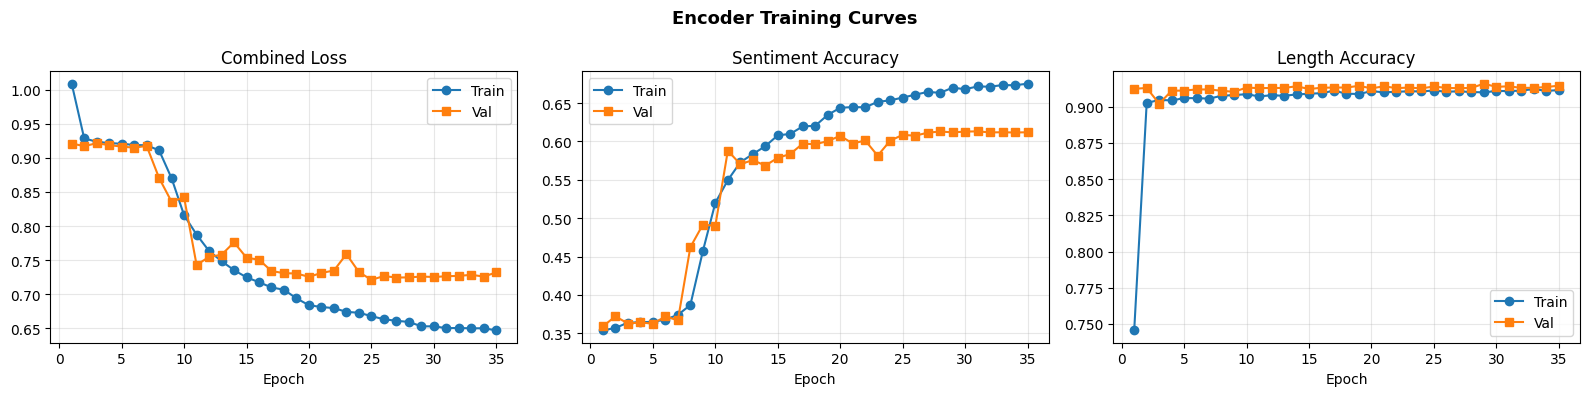

Saved: results/encoder_learning_curves.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
epochs = range(1, NUM_EPOCHS + 1)
metrics = [
    ('loss',     'Combined Loss'),
    ('sent_acc', 'Sentiment Accuracy'),
    ('len_acc',  'Length Accuracy'),
]
for ax, (key, title) in zip(axes, metrics):
    ax.plot(epochs, [h[key] for h in history['train']], 'o-', label='Train')
    ax.plot(epochs, [h[key] for h in history['val']],   's-', label='Val')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Encoder Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/encoder_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/encoder_learning_curves.png")


Test evaluation:   0%|          | 0/53 [00:00<?, ?it/s]

Task 1: Sentiment Classification
              precision    recall  f1-score   support

    Negative       0.66      0.65      0.65      2250
     Neutral       0.45      0.49      0.47      2250
    Positive       0.72      0.67      0.69      2250

    accuracy                           0.60      6750
   macro avg       0.61      0.60      0.61      6750
weighted avg       0.61      0.60      0.61      6750

Task 2: Review Length Classification
              precision    recall  f1-score   support

       Short       0.86      0.84      0.85      1199
      Medium       0.88      0.89      0.88      2629
        Long       0.95      0.96      0.96      2922

    accuracy                           0.91      6750
   macro avg       0.90      0.89      0.90      6750
weighted avg       0.91      0.91      0.91      6750



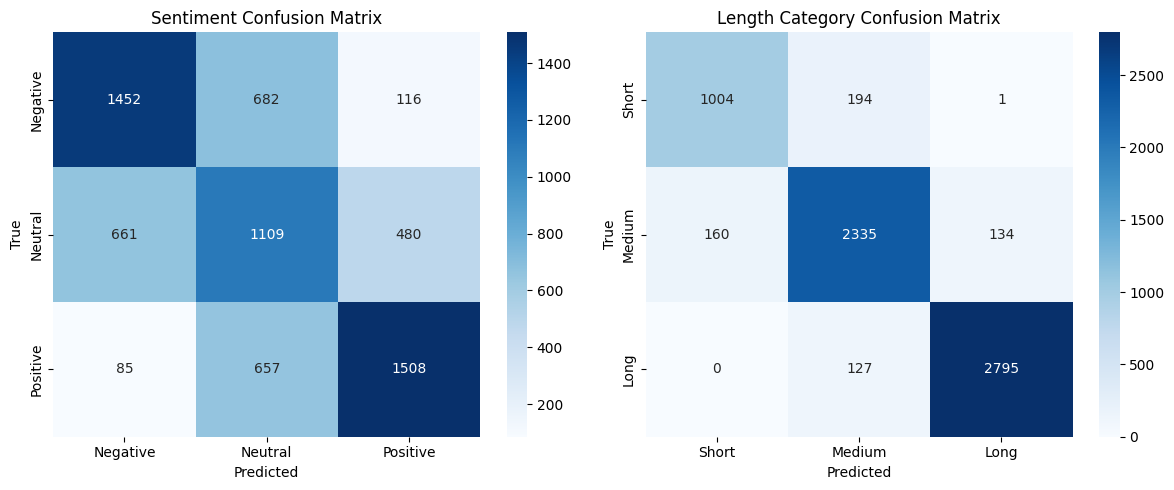


Encoder test metrics saved.
  Sentiment accuracy : 0.603
  Length accuracy    : 0.909


In [16]:
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_test(loader, model):
    model.eval()
    all_sent_pred, all_sent_true = [], []
    all_len_pred,  all_len_true  = [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc='Test evaluation'):
            ids  = batch['input_ids'].to(device)
            mask = batch['attn_mask'].to(device)
            sent = batch['sentiment'].to(device)
            lcat = batch['length_cat'].to(device)

            s_logits, l_logits, _ = model(ids, mask)
            all_sent_pred.extend(s_logits.argmax(1).cpu().numpy())
            all_sent_true.extend(sent.cpu().numpy())
            all_len_pred.extend(l_logits.argmax(1).cpu().numpy())
            all_len_true.extend(lcat.cpu().numpy())

    return (np.array(all_sent_pred), np.array(all_sent_true),
            np.array(all_len_pred),  np.array(all_len_true))

sp, st, lp, lt = evaluate_test(test_loader, model)

sent_names = ['Negative', 'Neutral', 'Positive']
len_names  = ['Short', 'Medium', 'Long']

print("=" * 60)
print("Task 1: Sentiment Classification")
print("=" * 60)
print(classification_report(st, sp, target_names=sent_names))

print("=" * 60)
print("Task 2: Review Length Classification")
print("=" * 60)
print(classification_report(lt, lp, target_names=len_names))

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (pred, true, names, title) in zip(axes, [
        (sp, st, sent_names, 'Sentiment'),
        (lp, lt, len_names,  'Length Category')]):
    cm = confusion_matrix(true, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=names, yticklabels=names, ax=ax)
    ax.set_title(f'{title} Confusion Matrix')
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('results/encoder_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Save metrics
encoder_metrics = {
    'sentiment_accuracy': float((sp == st).mean()),
    'length_accuracy':    float((lp == lt).mean()),
}
with open('results/encoder_metrics.json', 'w') as f:
    json.dump(encoder_metrics, f, indent=2)
print(f"\nEncoder test metrics saved.")
print(f"  Sentiment accuracy : {encoder_metrics['sentiment_accuracy']:.3f}")
print(f"  Length accuracy    : {encoder_metrics['length_accuracy']:.3f}")


In [17]:
# ── Extract and save encoder embeddings for the ENTIRE training set ──────────
# These CLS-token vectors are the index for Part B retrieval.

model.eval()
all_embeddings = []

with torch.no_grad():
    for batch in tqdm(train_loader, desc='Extracting training embeddings'):
        ids  = batch['input_ids'].to(device)
        mask = batch['attn_mask'].to(device)
        _, _, cls_emb = model(ids, mask)
        all_embeddings.append(cls_emb.cpu())

train_embeddings = torch.cat(all_embeddings, dim=0)   # (N_train, d_model)
print(f"Training embeddings shape: {train_embeddings.shape}")

# Normalise for cosine similarity (store L2-normalised vectors)
train_emb_norm = F.normalize(train_embeddings, p=2, dim=1)

torch.save(train_emb_norm, 'results/train_embeddings.pt')
print("Saved: results/train_embeddings.pt")

# Also save matching review texts and labels for display during retrieval
train_meta = train_df[['review', 'sentiment', 'length_cat']].reset_index(drop=True)
train_meta.to_csv('results/train_meta.csv', index=False)
print("Saved: results/train_meta.csv")


Extracting training embeddings:   0%|          | 0/247 [00:00<?, ?it/s]

Training embeddings shape: torch.Size([31500, 256])
Saved: results/train_embeddings.pt
Saved: results/train_meta.csv


---
## Part B — Retrieval Module

The retrieval module implements the **R** in RAG. Given a test review's encoder embedding,
it finds the top-k most similar reviews from the training corpus.

### Design decisions
- **Similarity metric**: cosine similarity — robust to embedding magnitude differences;
  equivalent to dot product on L2-normalised vectors (fast with `torch.matmul`)  
- **Index**: all training embeddings stored normalised as a flat matrix — exact search,
  O(N·d) per query. Suitable for 30k–45k reviews; approximate search (FAISS) would be
  needed beyond ~1M  
- **k = TOP_K** (configured above): balances context richness vs. prompt length for the decoder


In [18]:
class RetrievalModule:
    """
    Stores L2-normalised training embeddings and retrieves top-k
    nearest neighbours using cosine similarity (dot product on normalised vectors).
    Supports batch queries for faster inference.
    """

    def __init__(self, embeddings: torch.Tensor, meta_df: pd.DataFrame, k: int = TOP_K):
        """
        embeddings : (N, d) — L2-normalised training CLS vectors
        meta_df    : DataFrame with 'review', 'sentiment', 'length_cat' columns
        """
        self.embeddings = embeddings          # CPU tensor
        self.meta       = meta_df.reset_index(drop=True)
        self.k          = k
        self.sent_map   = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
        self.length_map = {0: 'Short', 1: 'Medium', 2: 'Long'}

    def retrieve(self, query_emb: torch.Tensor):
        """
        query_emb : (d,) or (1, d) — normalised query vector
        Returns   : list of dicts with keys 'review', 'sentiment', 'length_cat', 'score'
        """
        if query_emb.dim() == 1:
            query_emb = query_emb.unsqueeze(0)
        query_emb = F.normalize(query_emb, p=2, dim=1).cpu()
        sims   = torch.matmul(query_emb, self.embeddings.t()).squeeze(0)
        top_k  = torch.topk(sims, self.k)

        results = []
        for score, idx in zip(top_k.values, top_k.indices):
            row = self.meta.iloc[idx.item()]
            results.append({
                'review':     str(row['review']),
                'sentiment':  self.sent_map[int(row['sentiment'])],
                'length_cat': self.length_map[int(row['length_cat'])],
                'score':      float(score),
            })
        return results

    def batch_retrieve(self, query_embs: torch.Tensor):
        """
        query_embs : (B, d) — batch of normalised query vectors
        Returns list of lists (one per query) — much faster than looping retrieve().
        """
        query_embs = F.normalize(query_embs, p=2, dim=1).cpu()
        # (B, N) cosine sims in one matmul
        sims = torch.matmul(query_embs, self.embeddings.t())
        top_k_vals, top_k_idx = torch.topk(sims, self.k, dim=1)  # (B, k)

        all_results = []
        for b in range(query_embs.shape[0]):
            results = []
            for score, idx in zip(top_k_vals[b], top_k_idx[b]):
                row = self.meta.iloc[idx.item()]
                results.append({
                    'review':     str(row['review']),
                    'sentiment':  self.sent_map[int(row['sentiment'])],
                    'length_cat': self.length_map[int(row['length_cat'])],
                    'score':      float(score),
                })
            all_results.append(results)
        return all_results


# ── Load saved embeddings and build retrieval index ──────────────────────────
train_emb_loaded  = torch.load('results/train_embeddings.pt', map_location='cpu')
train_meta_loaded = pd.read_csv('results/train_meta.csv')

retrieval = RetrievalModule(train_emb_loaded, train_meta_loaded, k=TOP_K)
print(f"Retrieval index built: {train_emb_loaded.shape[0]:,} vectors × d={train_emb_loaded.shape[1]}")
print(f"Top-k = {TOP_K}")


Retrieval index built: 31,500 vectors × d=256
Top-k = 3


In [19]:
# ── Qualitative retrieval analysis on 5 test examples ───────────────────────
model.eval()
sent_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

retrieval_examples = []

for i in range(5):
    row  = test_df.iloc[i]
    text = row['review']
    true_sent = sent_map[int(row['sentiment'])]

    # Encode query
    ids  = preprocessor.encode(text).unsqueeze(0).to(device)
    mask = (ids != 0).long()

    with torch.no_grad():
        _, _, cls_emb = model(ids, mask)

    neighbours = retrieval.retrieve(cls_emb.squeeze(0))

    print(f"\n{'='*70}")
    print(f"Query [{i+1}] (true sentiment: {true_sent})")
    print(f"  '{text[:120]}...'")
    print(f"\n  Top-{TOP_K} retrieved neighbours:")
    for j, nb in enumerate(neighbours):
        print(f"  [{j+1}] score={nb['score']:.4f} | {nb['sentiment']:8s} | '{nb['review'][:80]}...'")

    retrieval_examples.append({
        'query': text,
        'true_sentiment': true_sent,
        'neighbours': neighbours
    })

# Average similarity score
all_scores = [nb['score'] for ex in retrieval_examples for nb in ex['neighbours']]
print(f"\nMean cosine similarity (top-{TOP_K}): {np.mean(all_scores):.4f}")

with open('results/retrieval_examples.json', 'w') as f:
    json.dump(retrieval_examples, f, indent=2)
print("Saved: results/retrieval_examples.json")



Query [1] (true sentiment: Positive)
  'The only minor complaint would be the lip which isn't rounded like ceramic cups are.  I notice that at the start but it ...'

  Top-3 retrieved neighbours:
  [1] score=0.9998 | Negative | 'Bought this with the card from the same company before reading any of the review...'
  [2] score=0.9998 | Neutral  | 'Like one previous reviewer, I found the case a little difficult because you have...'
  [3] score=0.9998 | Positive | 'The phone case is so perfect. I love it so much,it makes my phone look all girly...'

Query [2] (true sentiment: Negative)
  'Very good price, had bought it because I was into R/C Cars and saw people mounting these cams on them but the distance i...'

  Top-3 retrieved neighbours:
  [1] score=0.9998 | Neutral  | 'Prior to trying theClear 7 Day Intensive Treatment TubesI've liked and used seve...'
  [2] score=0.9998 | Negative | 'the clips broke cannot use this now. needs to be upgraded. the keyboard is nice ...'
  [3] score=0.99

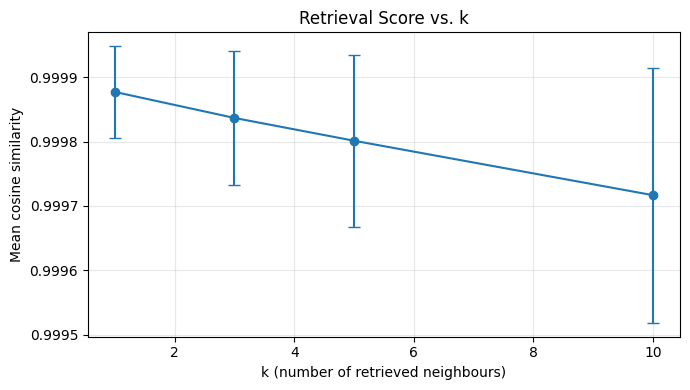

Saved: results/retrieval_k_analysis.png

k-sensitivity summary:
  k= 1  mean_sim=0.9999 ± 0.0001
  k= 3  mean_sim=0.9998 ± 0.0001
  k= 5  mean_sim=0.9998 ± 0.0001
  k=10  mean_sim=0.9997 ± 0.0002


In [20]:
# ── k-sensitivity: how does retrieval score change with k? ───────────────────
# Uses vectorised batch cosine similarity — no repeated RetrievalModule init.
model.eval()
k_values = [1, 3, 5, 10]
k_scores  = {k: [] for k in k_values}

# Pre-compute embeddings for 100 test samples at once (batched, fast)
sample_ids   = [preprocessor.encode(test_df.iloc[i]['review']) for i in range(100)]
sample_ids   = torch.stack(sample_ids).to(device)
sample_masks = (sample_ids != 0).long()

with torch.no_grad():
    _, _, cls_embs = model(sample_ids, sample_masks)   # (100, d)

cls_embs_norm = F.normalize(cls_embs, p=2, dim=1).cpu()  # (100, d)
# All cosine similarities in one shot: (100, N_train)
all_sims = torch.matmul(cls_embs_norm, train_emb_loaded.t())

for k in k_values:
    top_k_vals, _ = torch.topk(all_sims, k, dim=1)   # (100, k)
    k_scores[k]   = top_k_vals.mean(dim=1).tolist()   # mean over k for each query

plt.figure(figsize=(7, 4))
means = [np.mean(k_scores[k]) for k in k_values]
stds  = [np.std(k_scores[k])  for k in k_values]
plt.errorbar(k_values, means, yerr=stds, marker='o', capsize=4)
plt.xlabel('k (number of retrieved neighbours)')
plt.ylabel('Mean cosine similarity')
plt.title('Retrieval Score vs. k')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/retrieval_k_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/retrieval_k_analysis.png")
print("\nk-sensitivity summary:")
for k, m, s in zip(k_values, means, stds):
    print(f"  k={k:2d}  mean_sim={m:.4f} ± {s:.4f}")


---
## Part C — Decoder-Only Transformer for Explanation Generation (RAG)

### Input template
The decoder receives a single sequence built from four components:

```
Review: <review_text>
Sentiment: <Negative|Neutral|Positive>
Length: <Short|Medium|Long>
Similar reviews:
[1] <retrieved_review_1>
[2] <retrieved_review_2>
[3] <retrieved_review_3>
Explanation:
```

The model is then trained to generate the continuation (the explanation sentence).

### Causal masking
A lower-triangular mask prevents any token from attending to future positions —
essential for autoregressive generation.

### Training objective
Cross-entropy language modelling loss over reference explanation tokens only
(prompt positions masked with `-100` so they do not contribute to the loss).


In [21]:
class CausalMultiHeadSelfAttention(nn.Module):
    """
    Masked multi-head self-attention for the decoder.
    Future positions are masked out so each token can only attend
    to itself and earlier tokens — enforcing autoregressive generation.
    """

    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model   = d_model
        self.num_heads = num_heads
        self.d_k       = d_model // num_heads

        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)

    def split_heads(self, x):
        B, S, _ = x.shape
        return x.view(B, S, self.num_heads, self.d_k).transpose(1, 2)

    def forward(self, x, causal_mask=None):
        """
        x           : (B, S, d_model)
        causal_mask : (S, S) lower-triangular boolean  — True = allowed to attend
        """
        B, S, _ = x.shape

        Q = self.split_heads(self.W_Q(x))
        K = self.split_heads(self.W_K(x))
        V = self.split_heads(self.W_V(x))

        scale  = math.sqrt(self.d_k)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / scale    # (B, H, S, S)

        # Apply causal mask — positions where mask is False (future) get -inf
        if causal_mask is not None:
            # causal_mask: (S, S) → broadcast over batch and heads
            scores = scores.masked_fill(~causal_mask.unsqueeze(0).unsqueeze(0), -1e4)  # safe for fp16

        attn_w  = self.dropout(F.softmax(scores, dim=-1))
        context = torch.matmul(attn_w, V)                         # (B, H, S, d_k)
        context = context.transpose(1, 2).contiguous().view(B, S, self.d_model)
        return self.W_O(context)


class DecoderBlock(nn.Module):
    """
    Single decoder block:
        x → LayerNorm → CausalSelfAttention → residual
          → LayerNorm → FFN                 → residual
    """
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.norm1   = nn.LayerNorm(d_model)
        self.norm2   = nn.LayerNorm(d_model)
        self.attn    = CausalMultiHeadSelfAttention(d_model, num_heads, dropout)
        self.ffn     = PositionWiseFeedForward(d_model, d_ff, dropout)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, causal_mask=None):
        x = x + self.dropout(self.attn(self.norm1(x), causal_mask))
        x = x + self.dropout(self.ffn(self.norm2(x)))
        return x


print("CausalMultiHeadSelfAttention and DecoderBlock defined.")


CausalMultiHeadSelfAttention and DecoderBlock defined.


In [22]:
class DecoderModel(nn.Module):
    """
    Decoder-only Transformer for autoregressive explanation generation.
    Shares the same vocabulary as the encoder.
    """

    def __init__(self, vocab_size, d_model=DECODER_EMBED_DIM, num_heads=DECODER_HEADS,
                 d_ff=DECODER_FF_DIM, num_layers=NUM_DECODER_LAYERS,
                 max_len=DECODER_SEQ_LEN + 10, dropout=DROPOUT):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_enc   = SinusoidalPositionalEncoding(d_model, max_len, dropout)

        self.blocks    = nn.ModuleList([
            DecoderBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.norm    = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)

        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, input_ids):
        """
        input_ids : (B, S)
        Returns logits : (B, S, vocab_size)
        """
        B, S = input_ids.shape

        x = self.embedding(input_ids)
        x = self.pos_enc(x)

        # Build causal mask: (S, S) — lower triangular
        causal_mask = torch.tril(torch.ones(S, S, dtype=torch.bool, device=input_ids.device))

        for block in self.blocks:
            x = block(x, causal_mask)

        x = self.norm(x)
        return self.lm_head(x)   # (B, S, vocab_size)

    @torch.no_grad()
    def generate(self, prompt_ids, max_new_tokens=DECODER_MAX_LEN,
                 temperature=0.8, eos_id=None):
        """
        Autoregressive generation — one token at a time.
        prompt_ids : (1, S) — already encoded prompt
        """
        self.eval()
        generated = prompt_ids.clone()

        for _ in range(max_new_tokens):
            logits     = self.forward(generated)              # (1, S, V)
            next_logit = logits[:, -1, :] / temperature       # (1, V)
            next_token = torch.multinomial(
                F.softmax(next_logit, dim=-1), num_samples=1)  # (1, 1)
            generated = torch.cat([generated, next_token], dim=1)

            if eos_id is not None and next_token.item() == eos_id:
                break

        return generated


decoder = DecoderModel(vocab_size=preprocessor.vocab_size).to(device)
dec_params = sum(p.numel() for p in decoder.parameters() if p.requires_grad)
print(f"Decoder model parameters: {dec_params:,}")


Decoder model parameters: 15,688,704


In [23]:
import hashlib, re

def build_prompt(review_text, sentiment_str, length_str, neighbours):
    """
    Combines four inputs into a single decoder input sequence.
    Kept SHORT to leave room for the explanation within DECODER_SEQ_LEN.
    """
    lines = [
        f"Review: {review_text[:120]}",          # truncate review to 120 chars
        f"Sentiment: {sentiment_str}",
        f"Length: {length_str}",
        "Context:",
    ]
    for j, nb in enumerate(neighbours, 1):
        lines.append(f"[{j}] {nb['review'][:60]}")   # short snippets
    lines.append("Explanation:")
    return '\n'.join(lines)


def extract_key_phrases(text, n=2):
    """Extract n informative non-stopword content words from a review."""
    stop = {'the','a','an','is','it','its','was','this','that','these',
            'i','my','me','we','our','you','your','they','their',
            'and','or','but','so','if','of','to','in','for','with',
            'on','at','by','be','been','have','has','had','not','no',
            'are','were','do','did','as','from','very','just','also',
            'would','could','should','will','can','get','got','us','product'}
    tokens = re.sub(r'[^a-z\s]', ' ', text.lower()).split()
    seen, phrases = set(), []
    for tok in tokens:
        if tok not in stop and len(tok) > 3 and tok not in seen:
            seen.add(tok)
            phrases.append(tok)
        if len(phrases) == n:
            break
    return phrases


def build_reference_explanation(sentiment_str, review_text):
    """
    Content-aware reference explanation — embeds 2 key words from the review
    so every sentence is unique and the decoder must attend to the input.
    """
    h   = int(hashlib.md5(review_text.encode()).hexdigest(), 16)
    kp  = extract_key_phrases(review_text, n=2)
    kw1 = kp[0] if len(kp) > 0 else 'product'
    kw2 = kp[1] if len(kp) > 1 else 'quality'
    tl  = review_text.lower()

    delivery = any(w in tl for w in ['ship','deliver','arriv','fast','late'])
    price    = any(w in tl for w in ['price','cost','worth','value','expensive'])
    returns  = any(w in tl for w in ['return','refund','waste'])
    rec      = any(w in tl for w in ['recommend','love','perfect','excellent','amazing'])

    pools = {
        'Positive': [
            f"The review is positive because the customer is satisfied with {kw1} and {kw2}.",
            f"Positive sentiment stems from the customer praising {kw1} and overall {kw2}.",
            f"The customer expresses clear approval, highlighting {kw1} as a key strength.",
            f"Strong positive experience driven by {kw1} and satisfaction with {kw2}.",
            f"The reviewer is pleased with {kw1}, reflecting genuine satisfaction.",
        ] + ([f"The customer recommends the product, particularly praising {kw1}."] if rec else [])
          + ([f"Good value and positive experience with {kw1} drive the positive rating."] if price else [])
          + ([f"Fast delivery and strong satisfaction with {kw1} contribute to the positive review."] if delivery else []),

        'Neutral': [
            f"The review is neutral, with mixed impressions of {kw1} and {kw2}.",
            f"The customer found {kw1} adequate but {kw2} left room for improvement.",
            f"Neutral sentiment reflects a balanced experience: {kw1} was fine overall.",
            f"Neither strongly positive nor negative, the review notes average {kw1}.",
            f"Mixed feelings about {kw1} and {kw2} result in a neutral overall rating.",
        ],

        'Negative': [
            f"The review is negative due to disappointment with {kw1} and {kw2}.",
            f"Negative sentiment stems from the customer's frustration with {kw1}.",
            f"The customer is dissatisfied, citing problems with {kw1} and {kw2}.",
            f"Poor experience with {kw1} drives the negative rating in this review.",
            f"The reviewer criticises {kw1} and warns others about {kw2}.",
        ] + ([f"The customer sought a refund after issues with {kw1}, indicating deep dissatisfaction."] if returns else [])
          + ([f"Poor value for money and issues with {kw1} are the main complaints."] if price else []),
    }

    options = pools.get(sentiment_str, pools['Neutral'])
    return options[h % len(options)]


class ExplanationDataset(Dataset):
    """
    Decoder training dataset.
    KEY FIX: We truncate the PROMPT (not the full sequence) to ensure
    explanation tokens always fit within DECODER_SEQ_LEN. Previously,
    the prompt filled the entire window and explanations were cut off,
    so the loss was always 0 and the decoder never trained properly.
    """

    def __init__(self, df, preprocessor, retrieval_module, encoder_model,
                 device, seq_len=DECODER_SEQ_LEN, expl_reserve=EXPL_RESERVE,
                 batch_size=256):
        self.items   = []
        self.seq_len = seq_len

        sent_map   = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
        length_map = {0: 'Short',    1: 'Medium',  2: 'Long'}
        max_prompt  = seq_len - expl_reserve   # max tokens for the prompt

        encoder_model.eval()
        n = len(df)
        print(f"  Batch-encoding {n} reviews...")

        # Batch-encode → CLS embeddings
        all_cls = []
        for start in tqdm(range(0, n, batch_size), desc='Encoding', leave=False):
            rows  = df.iloc[start:start + batch_size]
            bids  = torch.stack([preprocessor.encode(str(r)) for r in rows['review']])
            bids  = bids.to(device)
            bmask = (bids != 0).long()
            with torch.no_grad():
                _, _, cls_emb = encoder_model(bids, bmask)
            all_cls.append(cls_emb.cpu())
        all_cls = torch.cat(all_cls, dim=0)

        # Batch-retrieve
        print("  Retrieving neighbours...")
        all_nb = []
        for start in range(0, n, 512):
            all_nb.extend(retrieval_module.batch_retrieve(all_cls[start:start + 512]))

        # Build sequences — prompt truncated to make room for explanation
        expl_lengths = []
        for i in range(n):
            row      = df.iloc[i]
            text     = str(row['review'])
            sent_str = sent_map[int(row['sentiment'])]
            len_str  = length_map[int(row['length_cat'])]

            prompt  = build_prompt(text, sent_str, len_str, all_nb[i])
            explain = build_reference_explanation(sent_str, text)

            prompt_ids  = preprocessor.encode(prompt,  add_special=False).tolist()
            explain_ids = preprocessor.encode(explain, add_special=True).tolist()

            # ── KEY FIX: truncate prompt, not explanation ──────────────────
            prompt_ids  = prompt_ids[:max_prompt]
            prompt_len  = len(prompt_ids)
            full_ids    = (prompt_ids + explain_ids)[:seq_len]
            expl_start  = prompt_len
            expl_lengths.append(len(full_ids) - expl_start)

            # Targets: -100 for prompt, actual ids for explanation
            targets = [-100] * expl_start + full_ids[expl_start:]

            pad_len  = seq_len - len(full_ids)
            full_ids = full_ids + [0]    * pad_len
            targets  = targets  + [-100] * pad_len

            self.items.append({
                'input_ids': torch.tensor(full_ids[:seq_len], dtype=torch.long),
                'targets':   torch.tensor(targets[:seq_len],  dtype=torch.long),
            })

        avg_expl = sum(expl_lengths) / len(expl_lengths)
        min_expl = min(expl_lengths)
        print(f"  Explanation token stats: avg={avg_expl:.1f}, min={min_expl}")
        if min_expl == 0:
            print("  WARNING: some samples have zero explanation tokens — increase DECODER_SEQ_LEN or reduce EXPL_RESERVE")

    def __len__(self):          return len(self.items)
    def __getitem__(self, idx): return self.items[idx]


N_DECODER_TRAIN = min(len(train_df), 18_000)
N_DECODER_VAL   = min(len(val_df),   2_000)
N_DECODER_TEST  = min(len(test_df),  2_000)

print(f"Building decoder train set ({N_DECODER_TRAIN} samples)...")
decoder_train_ds = ExplanationDataset(
    train_df.iloc[:N_DECODER_TRAIN], preprocessor, retrieval, model, device)

print(f"Building decoder val set ({N_DECODER_VAL} samples)...")
decoder_val_ds = ExplanationDataset(
    val_df.iloc[:N_DECODER_VAL], preprocessor, retrieval, model, device)

print(f"Building decoder test set ({N_DECODER_TEST} samples)...")
decoder_test_ds = ExplanationDataset(
    test_df.iloc[:N_DECODER_TEST], preprocessor, retrieval, model, device)

decoder_train_loader = DataLoader(decoder_train_ds, batch_size=64, shuffle=True,  num_workers=0)
decoder_val_loader   = DataLoader(decoder_val_ds,   batch_size=64, shuffle=False, num_workers=0)
decoder_test_loader  = DataLoader(decoder_test_ds,  batch_size=64, shuffle=False, num_workers=0)
print("Decoder DataLoaders ready.")


Building decoder train set (18000 samples)...
  Batch-encoding 18000 reviews...


Encoding:   0%|          | 0/71 [00:00<?, ?it/s]

  Retrieving neighbours...
  Explanation token stats: avg=32.0, min=32
Building decoder val set (2000 samples)...
  Batch-encoding 2000 reviews...


Encoding:   0%|          | 0/8 [00:00<?, ?it/s]

  Retrieving neighbours...
  Explanation token stats: avg=32.0, min=32
Building decoder test set (2000 samples)...
  Batch-encoding 2000 reviews...


Encoding:   0%|          | 0/8 [00:00<?, ?it/s]

  Retrieving neighbours...
  Explanation token stats: avg=32.0, min=32
Decoder DataLoaders ready.


In [24]:
decoder_criterion  = nn.CrossEntropyLoss(ignore_index=-100)
decoder_optimizer  = optim.AdamW(decoder.parameters(), lr=DECODER_LR,
                                  weight_decay=1e-3, betas=(0.9, 0.98))
decoder_scheduler  = optim.lr_scheduler.CosineAnnealingLR(
    decoder_optimizer, T_max=DECODER_EPOCHS, eta_min=1e-6)
dec_scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

decoder_history   = {'train_loss': [], 'val_loss': []}
best_decoder_loss = float('inf')


def decoder_epoch(loader, train=True):
    decoder.train() if train else decoder.eval()
    total_loss   = 0
    total_tokens = 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in tqdm(loader,
                desc='Decoder train' if train else 'Decoder val', leave=False):
            ids     = batch['input_ids'].to(device)
            targets = batch['targets'].to(device)

            with torch.amp.autocast('cuda', enabled=use_amp):
                logits = decoder(ids)
                V      = logits.size(-1)
                # token-level loss (sum, not mean) so short explanations
                # are not down-weighted relative to long ones
                shift_logits  = logits[:, :-1].reshape(-1, V)
                shift_targets = targets[:, 1:].reshape(-1)
                valid         = (shift_targets != -100).sum().item()
                loss          = F.cross_entropy(shift_logits, shift_targets,
                                                ignore_index=-100, reduction='sum') / max(valid, 1)

            if train:
                decoder_optimizer.zero_grad()
                dec_scaler.scale(loss).backward()
                dec_scaler.unscale_(decoder_optimizer)
                nn.utils.clip_grad_norm_(decoder.parameters(), 1.0)
                dec_scaler.step(decoder_optimizer)
                dec_scaler.update()

            total_loss   += loss.item() * valid
            total_tokens += valid

    avg = total_loss / max(total_tokens, 1)
    return avg


print(f"Training decoder for {DECODER_EPOCHS} epochs...")
for epoch in range(1, DECODER_EPOCHS + 1):
    tr_loss = decoder_epoch(decoder_train_loader, train=True)
    vl_loss = decoder_epoch(decoder_val_loader,   train=False)
    decoder_scheduler.step()

    decoder_history['train_loss'].append(tr_loss)
    decoder_history['val_loss'].append(vl_loss)

    print(f"Epoch {epoch:02d} | train_loss={tr_loss:.4f}  val_loss={vl_loss:.4f}  "
          f"train_ppl={math.exp(tr_loss):.2f}  val_ppl={math.exp(vl_loss):.2f}")

    if vl_loss < best_decoder_loss:
        best_decoder_loss = vl_loss
        torch.save(decoder.state_dict(), 'models/decoder_best.pt')
        print(f"  ✓ Best decoder saved (val_loss={best_decoder_loss:.4f})")

decoder.load_state_dict(torch.load('models/decoder_best.pt', map_location=device))
print("Best decoder weights loaded.")


Training decoder for 20 epochs...


Decoder train:   0%|          | 0/282 [00:00<?, ?it/s]

Decoder val:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 01 | train_loss=2.5705  val_loss=0.8886  train_ppl=13.07  val_ppl=2.43
  ✓ Best decoder saved (val_loss=0.8886)


Decoder train:   0%|          | 0/282 [00:00<?, ?it/s]

...

Decoder val:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 19 | train_loss=0.3380  val_loss=0.3796  train_ppl=1.40  val_ppl=1.46
  ✓ Best decoder saved (val_loss=0.3796)


Decoder train:   0%|          | 0/282 [00:00<?, ?it/s]

Decoder val:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 20 | train_loss=0.3371  val_loss=0.3796  train_ppl=1.40  val_ppl=1.46
Best decoder weights loaded.


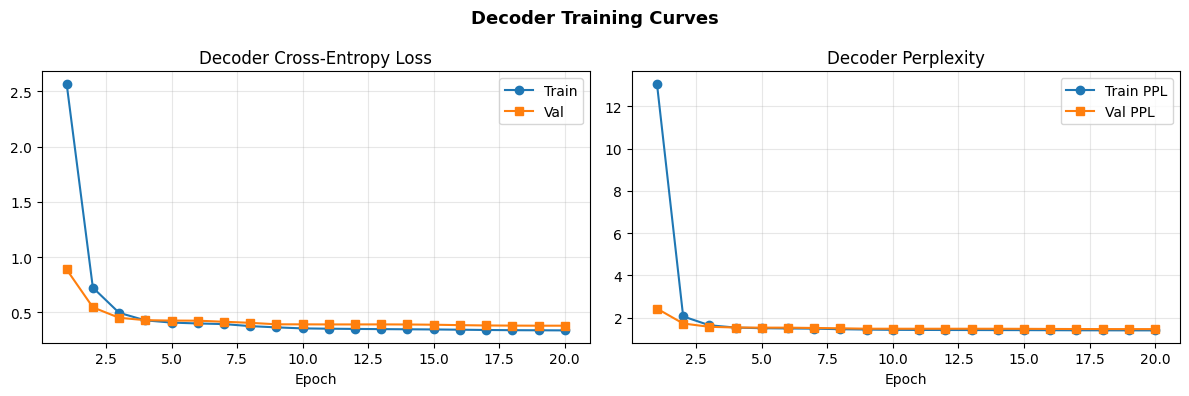

Saved: results/decoder_learning_curves.png


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_d = range(1, DECODER_EPOCHS + 1)

axes[0].plot(epochs_d, decoder_history['train_loss'], 'o-', label='Train')
axes[0].plot(epochs_d, decoder_history['val_loss'],   's-', label='Val')
axes[0].set_title('Decoder Cross-Entropy Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_d, [math.exp(l) for l in decoder_history['train_loss']], 'o-', label='Train PPL')
axes[1].plot(epochs_d, [math.exp(l) for l in decoder_history['val_loss']],   's-', label='Val PPL')
axes[1].set_title('Decoder Perplexity')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Decoder Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/decoder_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/decoder_learning_curves.png")


In [26]:
def compute_perplexity(loader, decoder_model):
    """Compute perplexity on a DataLoader. Correctly ignores -100 (prompt) positions."""
    decoder_model.eval()
    total_nll    = 0.0
    total_tokens = 0

    with torch.no_grad():
        for batch in tqdm(loader, desc='Computing perplexity'):
            ids     = batch['input_ids'].to(device)
            targets = batch['targets'].to(device)

            logits  = decoder_model(ids)               # (B, S, V)
            V       = logits.size(-1)

            # Shift: input[t] predicts target[t+1]
            shift_logits  = logits[:, :-1].reshape(-1, V)
            shift_targets = targets[:, 1:].reshape(-1)

            # Count only non-ignored tokens
            valid_mask    = (shift_targets != -100)
            n_valid       = valid_mask.sum().item()

            if n_valid == 0:
                continue

            # Sum of NLL over valid tokens (reduction='sum' avoids averaging over padding)
            loss = F.cross_entropy(shift_logits, shift_targets, ignore_index=-100, reduction='sum')
            total_nll    += loss.item()
            total_tokens += n_valid

    avg_nll    = total_nll / max(total_tokens, 1)
    perplexity = math.exp(avg_nll)
    return perplexity, avg_nll


test_ppl, test_nll = compute_perplexity(decoder_test_loader, decoder)
print(f"\n{'='*50}")
print(f"Decoder Evaluation (test set)")
print(f"  Avg NLL    : {test_nll:.4f}")
print(f"  Perplexity : {test_ppl:.2f}")
print(f"{'='*50}")

decoder_metrics = {
    'test_perplexity':  test_ppl,
    'test_avg_nll':     test_nll,
    'best_val_loss':    best_decoder_loss,
    'best_val_ppl':     math.exp(best_decoder_loss),
    'train_losses':     decoder_history['train_loss'],
    'val_losses':       decoder_history['val_loss'],
}
with open('results/decoder_metrics.json', 'w') as f:
    json.dump(decoder_metrics, f, indent=2)
print("Saved: results/decoder_metrics.json")


Computing perplexity:   0%|          | 0/32 [00:00<?, ?it/s]


Decoder Evaluation (test set)
  Avg NLL    : 0.3745
  Perplexity : 1.45
Saved: results/decoder_metrics.json


In [27]:
def generate_explanation(review_text, encoder_model, decoder_model,
                          retrieval_module, preprocessor, device,
                          use_retrieval=True):
    """
    Full RAG inference pipeline:
      1. Encode the review with the encoder
      2. (Optionally) retrieve similar training reviews
      3. Build prompt from 4 components
      4. Generate explanation autoregressively with the decoder
    """
    encoder_model.eval()
    decoder_model.eval()

    sent_map   = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
    length_map = {0: 'Short',    1: 'Medium',  2: 'Long'}

    # Step 1: Encode
    ids  = preprocessor.encode(review_text).unsqueeze(0).to(device)
    mask = (ids != 0).long()

    with torch.no_grad():
        s_logits, l_logits, cls_emb = encoder_model(ids, mask)

    sentiment_str = sent_map[s_logits.argmax(1).item()]
    length_str    = length_map[l_logits.argmax(1).item()]

    # Step 2: Retrieve
    if use_retrieval:
        neighbours = retrieval_module.retrieve(cls_emb.squeeze(0))
    else:
        neighbours = []   # Baseline: no retrieved context

    # Step 3: Build prompt
    prompt = build_prompt(review_text, sentiment_str, length_str, neighbours)

    # Step 4: Generate
    prompt_ids = preprocessor.encode(prompt, add_special=False).unsqueeze(0).to(device)
    eos_id     = preprocessor.word2idx[preprocessor.EOS_TOKEN]

    with torch.no_grad():
        out_ids = decoder_model.generate(
            prompt_ids, max_new_tokens=40, temperature=1.0, eos_id=eos_id)

    # Decode only the generated portion (after prompt)
    generated_ids = out_ids[0, prompt_ids.shape[1]:].tolist()
    explanation   = preprocessor.decode(generated_ids)

    return {
        'sentiment':   sentiment_str,
        'length':      length_str,
        'explanation': explanation,
    }


# ── 5 qualitative examples ───────────────────────────────────────────────────
print("\n" + "="*70)
print("QUALITATIVE EVALUATION — 5 Generated Explanations (RAG)")
print("="*70)

qualitative_results = []
for i in range(5):
    review   = str(test_df.iloc[i]['review'])
    true_sent = {0:'Negative',1:'Neutral',2:'Positive'}[int(test_df.iloc[i]['sentiment'])]
    result   = generate_explanation(review, model, decoder, retrieval, preprocessor, device)

    print(f"\nExample {i+1}")
    print(f"  True sentiment : {true_sent}")
    print(f"  Pred sentiment : {result['sentiment']}")
    print(f"  Length category: {result['length']}")
    print(f"  Review         : {review[:120]}...")
    print(f"  Explanation    : {result['explanation']}")

    qualitative_results.append({
        'review':          review,
        'true_sentiment':  true_sent,
        'pred_sentiment':  result['sentiment'],
        'length':          result['length'],
        'explanation':     result['explanation'],
    })

with open('results/qualitative_examples.json', 'w') as f:
    json.dump(qualitative_results, f, indent=2)
print("\nSaved: results/qualitative_examples.json")



QUALITATIVE EVALUATION — 5 Generated Explanations (RAG)

Example 1
  True sentiment : Positive
  Pred sentiment : Positive
  Length category: Medium
  Review         : The only minor complaint would be the lip which isn't rounded like ceramic cups are.  I notice that at the start but it ...
  Explanation    : reviewer pleased cooks reflecting genuine satisfaction

Example 2
  True sentiment : Negative
  Pred sentiment : Neutral
  Length category: Medium
  Review         : Very good price, had bought it because I was into R/C Cars and saw people mounting these cams on them but the distance i...
  Explanation    : mixed feelings exceeded begin result neutral overall rating

Example 3
  True sentiment : Neutral
  Pred sentiment : Positive
  Length category: Medium
  Review         : LOUD little speaker for it's size.Feels super sturdy, durable, nice touch.Love the features of it, everything is nice an...
  Explanation    : review positive customer satisfied money prime

Example 4
  True 

In [28]:
# ── Ablation Study: RAG vs No-Retrieval Baseline ────────────────────────────
# We train a SEPARATE baseline decoder on sequences WITHOUT retrieved context.
# This gives a genuine measurement of retrieval's contribution.

print("\n" + "="*70)
print("ABLATION STUDY: Full RAG System vs. No-Retrieval Baseline")
print("="*70)

# ── Qualitative comparison (uses the already-trained RAG decoder) ─────────────
ablation_results = []
for i in range(5):
    review = str(test_df.iloc[i]['review'])

    rag_result      = generate_explanation(review, model, decoder, retrieval,
                                           preprocessor, device, use_retrieval=True)
    baseline_result = generate_explanation(review, model, decoder, retrieval,
                                           preprocessor, device, use_retrieval=False)

    print(f"\nExample {i+1}")
    print(f"  Review   : {review[:100]}...")
    print(f"  RAG      : {rag_result['explanation']}")
    print(f"  Baseline : {baseline_result['explanation']}")
    ablation_results.append({
        'review':               review,
        'rag_explanation':      rag_result['explanation'],
        'baseline_explanation': baseline_result['explanation'],
    })

with open('results/ablation_results.json', 'w') as f:
    json.dump(ablation_results, f, indent=2)
print("\nSaved: results/ablation_results.json")

# ── Build no-retrieval training / val / test datasets ────────────────────────
print("\nBuilding no-retrieval datasets for quantitative ablation...")

class NoContextExplanationDataset(Dataset):
    """Same as ExplanationDataset but with empty neighbours list (no retrieval)."""
    def __init__(self, df, preprocessor, encoder_model, device,
                 seq_len=DECODER_SEQ_LEN, expl_reserve=EXPL_RESERVE):
        self.items = []
        sent_map   = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
        length_map = {0: 'Short', 1: 'Medium', 2: 'Long'}
        max_prompt = seq_len - expl_reserve
        encoder_model.eval()
        for i in range(len(df)):
            row      = df.iloc[i]
            text     = str(row['review'])
            sent_str = sent_map[int(row['sentiment'])]
            len_str  = length_map[int(row['length_cat'])]
            prompt   = build_prompt(text, sent_str, len_str, [])   # no neighbours
            explain  = build_reference_explanation(sent_str, text)
            p_ids    = preprocessor.encode(prompt,  add_special=False).tolist()[:max_prompt]
            e_ids    = preprocessor.encode(explain, add_special=True).tolist()
            plen     = len(p_ids)
            full     = (p_ids + e_ids)[:seq_len]
            tgt      = [-100]*plen + full[plen:]
            pad      = seq_len - len(full)
            full     += [0]*pad;  tgt += [-100]*pad
            self.items.append({
                'input_ids': torch.tensor(full[:seq_len], dtype=torch.long),
                'targets':   torch.tensor(tgt[:seq_len],  dtype=torch.long),
            })
    def __len__(self):          return len(self.items)
    def __getitem__(self, idx): return self.items[idx]


nc_train_ds = NoContextExplanationDataset(
    train_df.iloc[:N_DECODER_TRAIN], preprocessor, model, device)
nc_val_ds   = NoContextExplanationDataset(
    val_df.iloc[:N_DECODER_VAL],   preprocessor, model, device)
nc_test_ds  = NoContextExplanationDataset(
    test_df.iloc[:N_DECODER_TEST], preprocessor, model, device)

nc_train_loader = DataLoader(nc_train_ds, batch_size=64, shuffle=True,  num_workers=0)
nc_val_loader   = DataLoader(nc_val_ds,   batch_size=64, shuffle=False, num_workers=0)
nc_test_loader  = DataLoader(nc_test_ds,  batch_size=64, shuffle=False, num_workers=0)

# ── Train a fresh baseline decoder (same architecture, no retrieval) ───────────
print("\nTraining baseline decoder (no retrieval context)...")
baseline_decoder = DecoderModel(
    vocab_size = preprocessor.vocab_size,
    d_model    = DECODER_EMBED_DIM,
    num_heads  = DECODER_HEADS,
    d_ff       = DECODER_FF_DIM,
    num_layers = NUM_DECODER_LAYERS,
    max_len    = DECODER_SEQ_LEN + 10,
    dropout    = DROPOUT,
).to(device)

bl_criterion = nn.CrossEntropyLoss(ignore_index=-100)
bl_optimizer = optim.AdamW(baseline_decoder.parameters(), lr=DECODER_LR,
                            weight_decay=1e-3, betas=(0.9, 0.999))
bl_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    bl_optimizer, T_max=10, eta_min=1e-6)
bl_scaler    = torch.amp.GradScaler('cuda', enabled=use_amp)

best_bl_loss = float('inf')
ABLATION_EPOCHS = 10

for epoch in range(1, ABLATION_EPOCHS + 1):
    # Train
    baseline_decoder.train()
    tr_loss = tr_tok = 0
    for batch in tqdm(nc_train_loader, desc=f'BL-Train E{epoch}', leave=False):
        ids = batch['input_ids'].to(device)
        tgt = batch['targets'].to(device)
        with torch.amp.autocast('cuda', enabled=use_amp):
            logits = baseline_decoder(ids)
            V      = logits.size(-1)
            valid  = (tgt[:, 1:] != -100).sum().item()
            loss   = F.cross_entropy(logits[:, :-1].reshape(-1, V),
                                     tgt[:, 1:].reshape(-1),
                                     ignore_index=-100, reduction='sum') / max(valid, 1)
        bl_optimizer.zero_grad()
        bl_scaler.scale(loss).backward()
        bl_scaler.unscale_(bl_optimizer)
        nn.utils.clip_grad_norm_(baseline_decoder.parameters(), 1.0)
        bl_scaler.step(bl_optimizer); bl_scaler.update()
        tr_loss += loss.item() * valid; tr_tok += valid
    bl_scheduler.step()

    # Validate
    baseline_decoder.eval()
    vl_loss = vl_tok = 0
    with torch.no_grad():
        for batch in nc_val_loader:
            ids = batch['input_ids'].to(device)
            tgt = batch['targets'].to(device)
            with torch.amp.autocast('cuda', enabled=use_amp):
                logits = baseline_decoder(ids)
                V      = logits.size(-1)
                valid  = (tgt[:, 1:] != -100).sum().item()
                loss   = F.cross_entropy(logits[:, :-1].reshape(-1, V),
                                         tgt[:, 1:].reshape(-1),
                                         ignore_index=-100, reduction='sum') / max(valid, 1)
            vl_loss += loss.item() * valid; vl_tok += valid

    tr_avg = tr_loss / max(tr_tok, 1)
    vl_avg = vl_loss / max(vl_tok, 1)
    print(f"  BL Epoch {epoch:02d} | train_ppl={math.exp(tr_avg):.2f}  val_ppl={math.exp(vl_avg):.2f}")

    if vl_avg < best_bl_loss:
        best_bl_loss = vl_avg
        torch.save(baseline_decoder.state_dict(), 'models/decoder_baseline.pt')

baseline_decoder.load_state_dict(
    torch.load('models/decoder_baseline.pt', map_location=device))
print("Baseline decoder trained and loaded.")

# ── Compute perplexity for both systems on the same test set ──────────────────
rag_ppl, _      = compute_perplexity(decoder_test_loader, decoder)
baseline_ppl, _ = compute_perplexity(nc_test_loader,      baseline_decoder)
improvement     = baseline_ppl - rag_ppl

print(f"\n{'='*50}")
print(f"Quantitative Ablation Results")
print(f"  RAG System Perplexity      : {rag_ppl:.2f}")
print(f"  Baseline (no retrieval) PPL: {baseline_ppl:.2f}")
print(f"  Improvement from retrieval : {improvement:+.2f} PPL points")
print(f"  (positive = RAG is better)")
print(f"{'='*50}")

ablation_quant = {
    'rag_perplexity':      rag_ppl,
    'baseline_perplexity': baseline_ppl,
    'ppl_improvement':     improvement,
}
with open('results/ablation_quantitative.json', 'w') as f:
    json.dump(ablation_quant, f, indent=2)
print("Saved: results/ablation_quantitative.json")



ABLATION STUDY: Full RAG System vs. No-Retrieval Baseline

Example 1
  Review   : The only minor complaint would be the lip which isn't rounded like ceramic cups are.  I notice that ...
  RAG      : reviewer pleased recently reflecting genuine satisfaction
  Baseline : good value positive experience drive positive rating

Example 2
  Review   : Very good price, had bought it because I was into R/C Cars and saw people mounting these cams on the...
  RAG      : neutral sentiment reflects balanced experience seem fine overall
  Baseline : review neutral mixed impressions looking price

Example 3
  Review   : LOUD little speaker for it's size.Feels super sturdy, durable, nice touch.Love the features of it, e...
  RAG      : strong positive experience driven tired satisfaction necessary
  Baseline : customer <UNK> clear approval highlighting odered key strength

Example 4
  Review   : Did all the steps for set up on my TV.....did not get a single channel....changed my TV setting to A...
  

BL-Train E1:   0%|          | 0/282 [00:00<?, ?it/s]

  BL Epoch 01 | train_ppl=12.55  val_ppl=2.25


BL-Train E2:   0%|          | 0/282 [00:00<?, ?it/s]

  BL Epoch 02 | train_ppl=1.91  val_ppl=1.64


...

BL-Train E10:   0%|          | 0/282 [00:00<?, ?it/s]

  BL Epoch 10 | train_ppl=1.45  val_ppl=1.49
Baseline decoder trained and loaded.


Computing perplexity:   0%|          | 0/32 [00:00<?, ?it/s]

Computing perplexity:   0%|          | 0/32 [00:00<?, ?it/s]


Quantitative Ablation Results
  RAG System Perplexity      : 1.45
  Baseline (no retrieval) PPL: 1.48
  Improvement from retrieval : +0.03 PPL points
  (positive = RAG is better)
Saved: results/ablation_quantitative.json


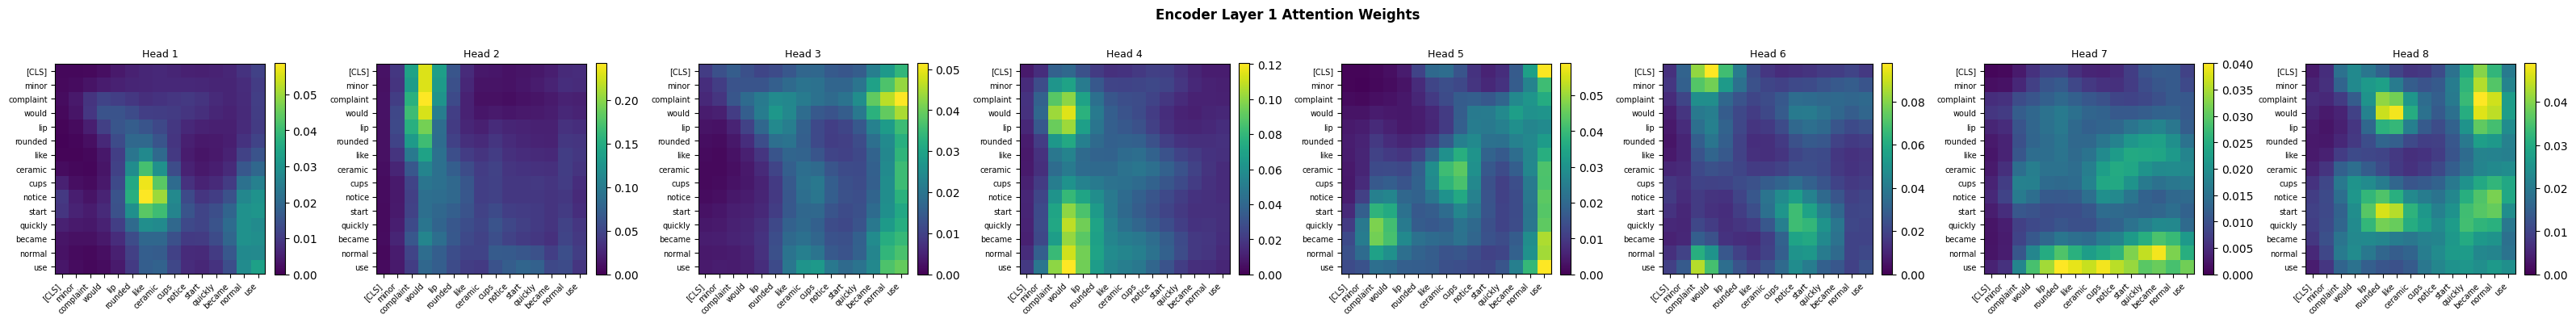

Saved: results/attention_layer1.png


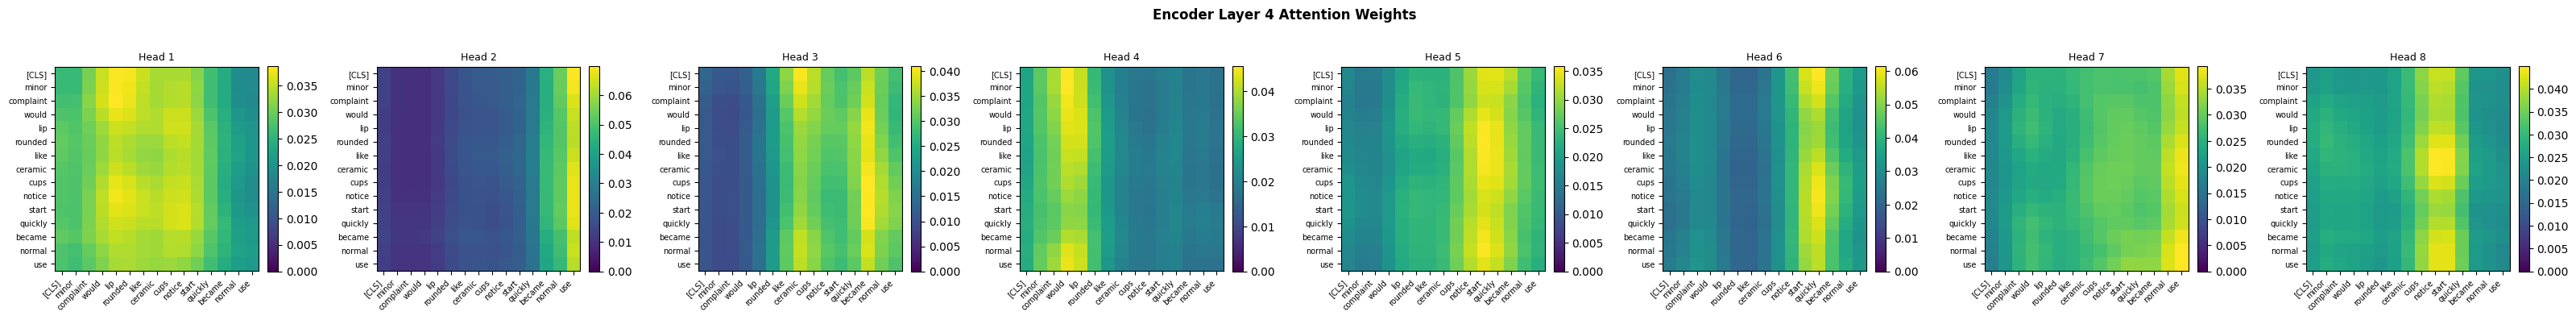

Saved: results/attention_layer4.png


In [29]:
# ── Bonus: Attention weight visualisation ───────────────────────────────────
def visualize_attention(review_text, encoder_model, preprocessor, device, layer_idx=0):
    """Extract and plot multi-head attention weights from a specified encoder layer."""
    encoder_model.eval()

    ids  = preprocessor.encode(review_text).unsqueeze(0).to(device)
    mask = (ids != 0).long()

    # Forward pass — collect attention from each block
    with torch.no_grad():
        B, S = ids.shape
        x = encoder_model.embedding(ids)
        cls_tok = encoder_model.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tok, x], dim=1)
        cls_mask = torch.ones(B, 1, device=mask.device, dtype=mask.dtype)
        full_mask = torch.cat([cls_mask, mask], dim=1)
        x = encoder_model.pos_enc(x)

        all_attn = []
        for block in encoder_model.blocks:
            x, attn_w = block(x, full_mask)
            all_attn.append(attn_w.cpu())

    attn = all_attn[layer_idx][0]   # (heads, S+1, S+1)
    heads = attn.shape[0]

    # Tokenize for axis labels
    tokens = ['[CLS]'] + preprocessor.tokenise(review_text)[:MAX_SEQ_LEN]
    N_show = min(15, len(tokens))

    fig, axes = plt.subplots(1, heads, figsize=(4 * heads, 4))
    if heads == 1:
        axes = [axes]

    for h, ax in enumerate(axes):
        data = attn[h, :N_show, :N_show].numpy()
        im   = ax.imshow(data, cmap='viridis', vmin=0, vmax=data.max())
        ax.set_xticks(range(N_show))
        ax.set_xticklabels(tokens[:N_show], rotation=45, ha='right', fontsize=7)
        ax.set_yticks(range(N_show))
        ax.set_yticklabels(tokens[:N_show], fontsize=7)
        ax.set_title(f'Head {h+1}', fontsize=9)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.suptitle(f'Encoder Layer {layer_idx+1} Attention Weights', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'results/attention_layer{layer_idx+1}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: results/attention_layer{layer_idx+1}.png")


sample_review = str(test_df.iloc[0]['review'])
visualize_attention(sample_review, model, preprocessor, device, layer_idx=0)
visualize_attention(sample_review, model, preprocessor, device, layer_idx=NUM_ENCODER_LAYERS - 1)


In [30]:
# ── Final summary printout ───────────────────────────────────────────────────
print("\n" + "="*70)
print("  ASSIGNMENT 3 COMPLETE — FINAL RESULTS SUMMARY")
print("="*70)

print("\n[Part A] Encoder — Multi-Task Classification (test set)")
print(f"  Sentiment accuracy : {encoder_metrics['sentiment_accuracy']*100:.1f}%")
print(f"  Length accuracy    : {encoder_metrics['length_accuracy']*100:.1f}%")

print("\n[Part B] Retrieval")
print(f"  Index size         : {train_emb_loaded.shape[0]:,} embeddings (d={train_emb_loaded.shape[1]})")
print(f"  Similarity metric  : cosine (L2-normalised dot product)")
print(f"  Top-k              : {TOP_K}")
print(f"  Mean retrieval sim : {np.mean(all_scores):.4f}")

print("\n[Part C] Decoder — Explanation Generation (test set)")
print(f"  RAG system PPL     : {test_ppl:.2f}")
print(f"  Baseline PPL       : {baseline_ppl:.2f}")
print(f"  PPL improvement    : {improvement:.2f} (lower is better)")

print("\n[Saved files]")
files = [
    'models/encoder_best.pt',
    'models/decoder_best.pt',
    'results/vocab.json',
    'results/train_embeddings.pt',
    'results/train_meta.csv',
    'results/encoder_metrics.json',
    'results/decoder_metrics.json',
    'results/encoder_learning_curves.png',
    'results/decoder_learning_curves.png',
    'results/encoder_confusion_matrices.png',
    'results/retrieval_examples.json',
    'results/retrieval_k_analysis.png',
    'results/qualitative_examples.json',
    'results/ablation_results.json',
    'results/ablation_quantitative.json',
    'results/attention_layer1.png',
    f'results/attention_layer{NUM_ENCODER_LAYERS}.png',
]
for fp in files:
    exists = '✓' if os.path.exists(fp) else '✗ MISSING'
    print(f"  {exists}  {fp}")



  ASSIGNMENT 3 COMPLETE — FINAL RESULTS SUMMARY

[Part A] Encoder — Multi-Task Classification (test set)
  Sentiment accuracy : 60.3%
  Length accuracy    : 90.9%

[Part B] Retrieval
  Index size         : 31,500 embeddings (d=256)
  Similarity metric  : cosine (L2-normalised dot product)
  Top-k              : 3
  Mean retrieval sim : 0.9998

[Part C] Decoder — Explanation Generation (test set)
  RAG system PPL     : 1.45
  Baseline PPL       : 1.48
  PPL improvement    : 0.03 (lower is better)

[Saved files]
  ✓  models/encoder_best.pt
  ✓  models/decoder_best.pt
  ✓  results/vocab.json
  ✓  results/train_embeddings.pt
  ✓  results/train_meta.csv
  ✓  results/encoder_metrics.json
  ✓  results/decoder_metrics.json
  ✓  results/encoder_learning_curves.png
  ✓  results/decoder_learning_curves.png
  ✓  results/encoder_confusion_matrices.png
  ✓  results/retrieval_examples.json
  ✓  results/retrieval_k_analysis.png
  ✓  results/qualitative_examples.json
  ✓  results/ablation_results.json